# 1. Membaca Dataset Mall Customers
Pada langkah ini, kita mengimpor pustaka pandas dan membaca file dataset Mall_Customers.csv, kemudian menampilkan 5 baris pertama data.

In [1]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 2. Cek Missing Values
Memeriksa keberadaan nilai yang hilang (*missing values*) pada setiap kolom dataset.

In [12]:
# cek missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64

# 3. Statistik Deskriptif Dataset
Menampilkan ringkasan statistik deskriptif (seperti rata-rata, nilai minimum, maksimum, dan standar deviasi) dari variabel numerik.

In [22]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,2.010000
std,57.879185,13.969007,26.264721,25.823522,1.840335
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,2.000000
75%,150.250000,49.000000,78.000000,73.000000,4.000000
max,200.000000,70.000000,137.000000,99.000000,5.000000


# 4. Mengambil Fitur Annual Income dan Spending Score
Mengambil kolom Annual Income (k$) dan Spending Score (1-100) (mulai dari indeks kolom ke-3) untuk analisis 2 dimensi awal.

In [23]:
dataset = df.iloc[:,3:]
dataset.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,5
1,15,81,2
2,16,6,5
3,16,77,2
4,17,40,5


# 5. Mendefinisikan Variabel X dan Y
Menyimpan fitur Annual Income ke dalam variabel x dan Spending Score ke dalam variabel y.

In [24]:
x = df.iloc[:, 3]
y = df.iloc[:, 4]

# 6. Visualisasi Scatter Plot 2D Awal
Menampilkan sebaran data awal antara Annual Income dan Spending Score menggunakan matplotlib.

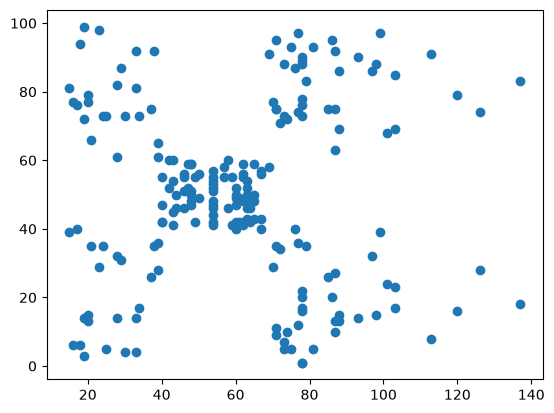

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

# 7. Feature Scaling & Elbow Method (2D)
Melakukan penormalan data menggunakan MinMaxScaler, lalu menentukan jumlah klaster optimal ($k$) dengan metode *Elbow* berdasarkan nilai WCSS (*Within-Cluster Sum of Squares*).

c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

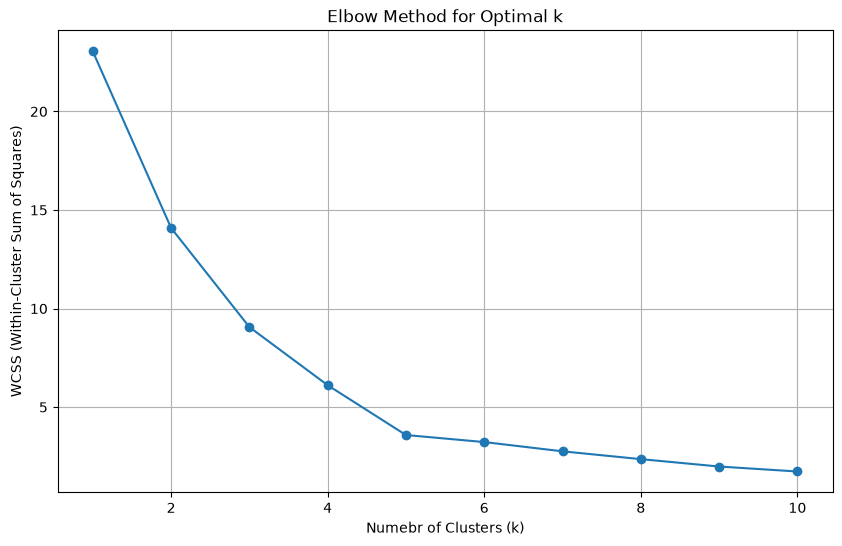

In [26]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()

# Mengambil kolom X (index 3) dan Y (index 4) dari DataFrame
X = pd.DataFrame({'Annual Income (k$)': x, 'Spending Score (1-100)': y})

X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal menggunakan Elbow Method
wcss = []
for i in range(1, 11):  # Coba k dari 1 sampai 10
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Membuat plow Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Numebr of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

# 8. K-Means Clustering 2D dengan k=5
Berdasarkan hasil Elbow Method, nilai $k$ optimal yang dipilih adalah 5. Selanjutnya dilakukan pembentukan klaster dan visualisasi scatter plot berlabel warna klaster.

c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


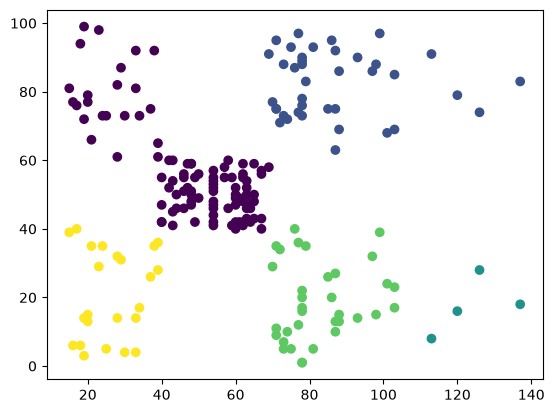

In [27]:
# dari elbow method, nilai k optimal untuk data ini adalah 5
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)

# Plot hasil klaster
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

# 9. Visualisasi Scatter Plot 3D Awal
Melakukan klasterisasi tahap berikutnya dengan menggunakan 3 fitur utama: Age (X), Annual Income (Y), dan Spending Score (Z).

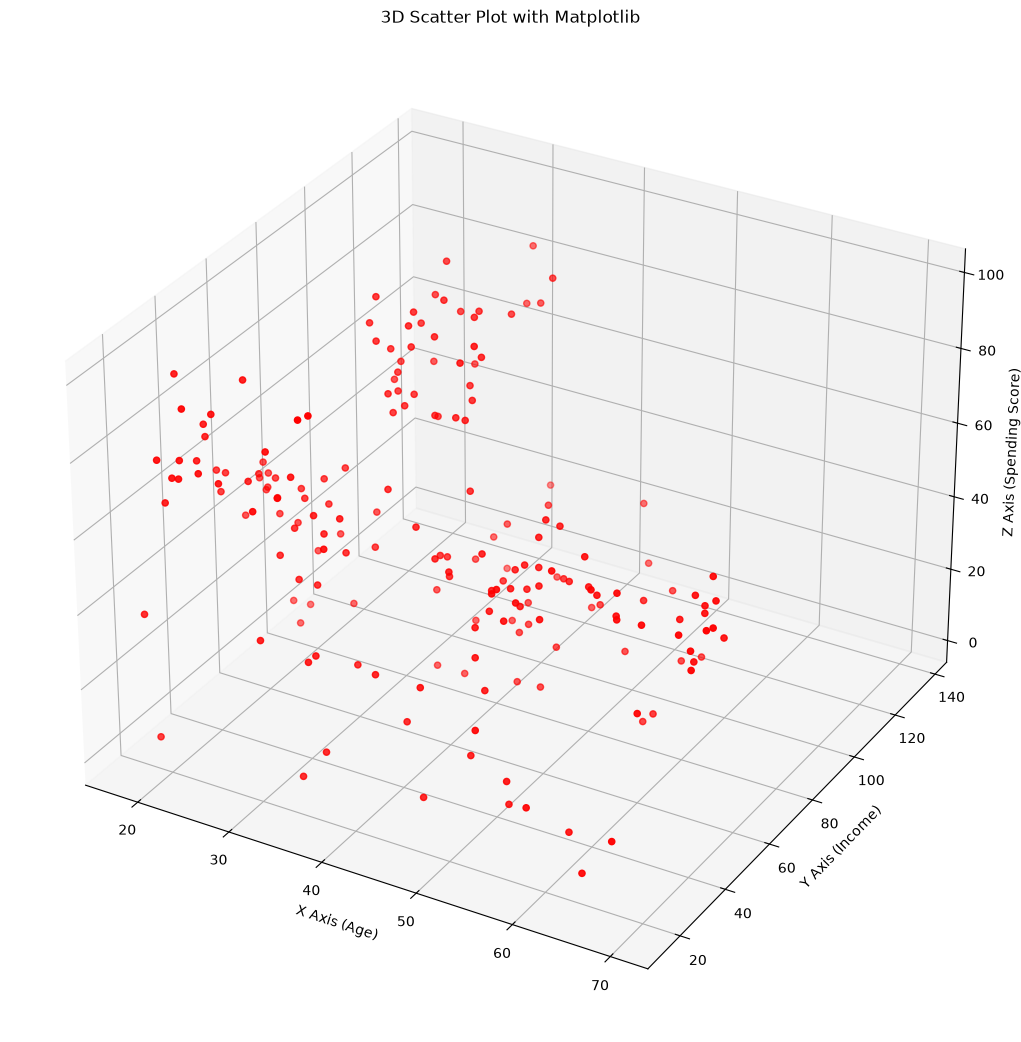

In [28]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Data Age, Annual Income, dan Spending Score
x = df.iloc[:, 2]
y = df.iloc[:, 3]
z = df.iloc[:, 4]

# Membuat plot 3D
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Plot data
ax.scatter(x, y, z, c='red', marker='o')

# Label sumbu
ax.set_xlabel('X Axis (Age)')
ax.set_ylabel('Y Axis (Income)')
ax.set_zlabel('Z Axis (Spending Score)')

plt.title('3D Scatter Plot with Matplotlib')
plt.show()

# 10. Feature Scaling & Elbow Method (3D)
Menggabungkan ketiga fitur ke dalam matriks data, menormalisasinya dengan MinMaxScaler, lalu mencari nilai $k$ optimal kembali dengan metode *Elbow*.

c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

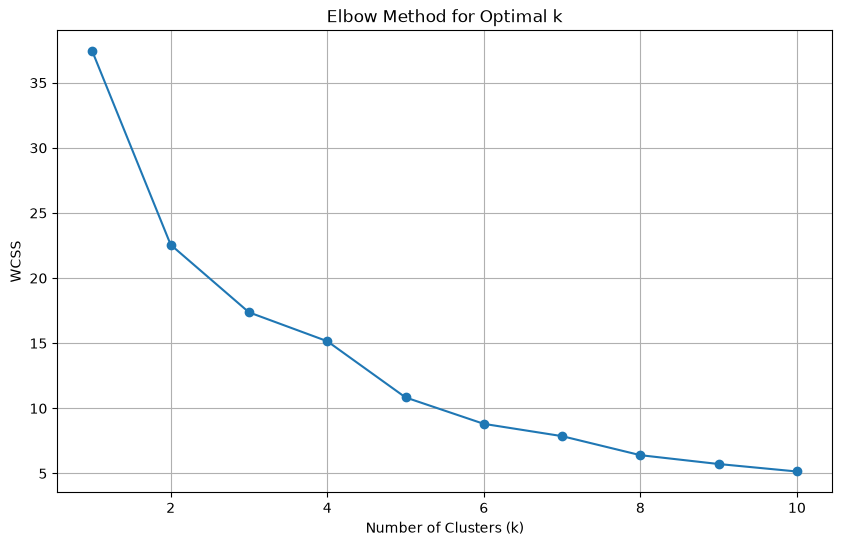

In [29]:
# Menggabungkan data X, Y, dan Z menjadi array untuk clustering
X = np.array(list(zip(x, y, z)))

# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal dengan Elbow Method
wcss = []
for i in range(1, 11):  
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualisasi ELbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# 11. K-Means Clustering 3D dengan k=6 dan Visualisasi
Berdasarkan evaluasi *Elbow Method* pada 3 fitur, nilai $k=6$ dipilih sebagai jumlah klaster. Hasil klasterisasi dimasukkan ke kolom Cluster pada DataFrame dan divisualisasikan dalam bentuk grafik 3D.

c:\Users\WIN11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


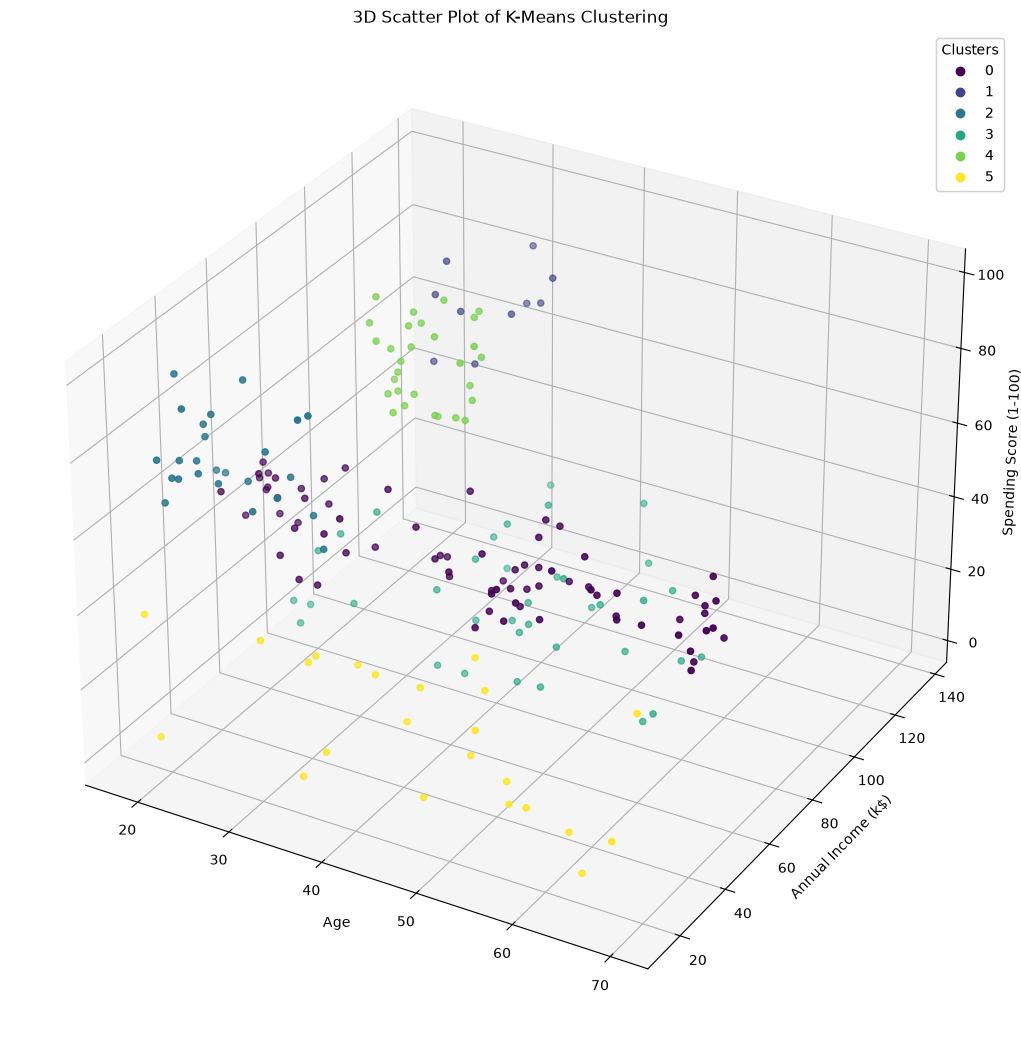

In [30]:
# Pilih k optimal setelah melihat Elbow 
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X)

# Menambahkan hasil klaster ke DataFrame
df['Cluster'] = clusters

# Visualisasi 3D Hasil K-Means

# Plot data dengan warna berdasarkan klaster
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Plot setiap titik dengan warna sesuai karakter
scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis', marker='o')

# Label Sumbu
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

# Menampilkan legenda klaster
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.title('3D Scatter Plot of K-Means Clustering')
plt.show()